<a href="https://colab.research.google.com/github/asit18/ai-ml/blob/main/Assignment_8_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Required Assignment 8.1: Scikit-Learn Pipelines

**Estimated time: 60 minutes**

**Total Points: 24 Points**

This activity focuses on using the pipeline functionality of scikit-learn to combine a transformer with an estimator.  Specifically, you will combine the process of generating polynomial features with that of building a linear regression model.  You will use the `Pipeline` functionality from the `sklearn.pipeline` module to construct both a quadratic and cubic model.

## Index:

 - [Problem 1](#Problem-1)
 - [Problem 2](#Problem-2)
 - [Problem 3](#Problem-3)
 - [Problem 4](#Problem-4)
 - [Problem 5](#Problem-5)
 - [Problem 6](#Problem-6)

In [1]:
import numpy as np
import pandas as pd
import warnings
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")

### The Data

The data will again be the automobile dataset.  You are to use the pipelines to build quadratic features and linear models using `horsepower` to predict `mpg`.   

In [2]:
auto = pd.read_csv('data/auto.csv')

In [3]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


[Back to top](#Index:)

## Problem 1

### Creating a `Pipeline`

**4 Points**

Use `Pipeline` to create a pipeline object. Inside the pipeline object, define a tuple where the first element is a string identifier `quad_features` and the second element is an instance of `PolynomialFeatures` of degree `2`. Inside the pipeline define another tuple where the first element is a string identifier `quad_model`, and the second element is an instance of `LinearRegression`. Assign the pipeline object to the variable `pipe`.

In [4]:
### GRADED

pipe = ''

### BEGIN SOLUTION
pipe = Pipeline([('quad_features', PolynomialFeatures(degree = 2)), ('quad_model', LinearRegression())])
### END SOLUTION

# Answer check
print(type(pipe))
print(pipe.named_steps)

<class 'sklearn.pipeline.Pipeline'>
{'quad_features': PolynomialFeatures(), 'quad_model': LinearRegression()}


[Back to top](#Index:)

## Problem 2

### Fitting the Pipeline

**4 Points**

Complete the code below according to the following instructions:

- Assign to the variable `X` the values of the `horsepower` of `auto`.
- Assign to the variable `y` the values of the `mpg` of `auto`.
- Use the function `fit` on `pipe` to train your model on `X` and `y`.
- Determine the `mean_squared_error` of your model, and assign the value as a float to `quad_pipe_mse` below.  

In [5]:
### GRADED

X = ''
y = ''

quad_pipe_mse = ''

### BEGIN SOLUTION
pipe = Pipeline([('quad_features', PolynomialFeatures(degree = 2)), ('quad_model', LinearRegression())])
X = auto[['horsepower']]
y = auto['mpg']
pipe.fit(X, y)
quad_pipe_mse = float(mean_squared_error(y, pipe.predict(X)))
### END SOLUTION

# Answer check
print(type(quad_pipe_mse))
print(quad_pipe_mse)

<class 'float'>
18.98476890761722


[Back to top](#Index:)

## Problem 3

### Examining the Coefficients

**4 Points**

Now, to examine the coefficients, use the `.named_steps` attribute on the `pipe` object to extract the regressor.  Assign the model to `quad_reg` below.  

Extract the coefficients from the model and assign these as an array to the variable `coefs`.

In [6]:
### GRADED

quad_reg = '' #regressor from pipeline
coefs = '' #coefficients of regressor

### BEGIN SOLUTION
pipe = Pipeline([('quad_features', PolynomialFeatures(degree = 2)), ('quad_model', LinearRegression())])
X = auto[['horsepower']]
y = auto['mpg']
pipe.fit(X, y)
quad_reg = pipe.named_steps['quad_model']
coefs = quad_reg.coef_
### END SOLUTION

# Answer check
print(type(quad_reg))
print(coefs)

<class 'sklearn.linear_model._base.LinearRegression'>
[ 0.         -0.46618963  0.00123054]


[Back to top](#Index:)

## Problem 4

### Considering the Bias

**4 Points**

Not that your coefficients have 3 values.  Your model also contains an intercept term though, and this leads to one more value than expected from a quadratic model with one input feature.  This is due to the inclusion of the bias term using `PolynomialFeatures` and the intercept term added with the `fit_intercept = True` default setting in the regressor.  


To get the appropriate model coefficients and intercept, you can set `include_bias = False` in the `PolynomialFeatures` transformer.  

Complete the code according to the instructions below:

- Use `Pipeline` to create a pipeline object. Inside the pipeline object, define a a tuple where the first element is a string identifier `quad_features` and the second element is an instance of `PolynomialFeatures` of degree `2` with `include_bias = False`. Inside the pipeline define another tuple where the first element is a string identifier `quad_model`, and the second element is an instance of `LinearRegression`. Assign the pipeline object to the variable `pipe_no_bias`.
- Use the `fit` function on `pipe_no_bias` to train your model on `X` and `y`.
- Use the `mean_squared_error` function to calculate the MSE between `y` and `pipe_no_bias.predict(X)`. Assign the result as a float `no_bias_mse`.



In [7]:
### GRADED

pipe_no_bias = '' #pipeline with no bias in transformer
no_bias_mse = '' #mean squared error of new model

### BEGIN SOLUTION
pipe_no_bias = Pipeline([('quad_features', PolynomialFeatures(degree = 2, include_bias=False)), ('quad_model', LinearRegression())])
X = auto[['horsepower']]
y = auto['mpg']
pipe_no_bias.fit(X, y)
no_bias_mse = float(mean_squared_error(y, pipe_no_bias.predict(X)))
### END SOLUTION

# Answer check
print(type(pipe_no_bias))
print(no_bias_mse)

<class 'sklearn.pipeline.Pipeline'>
18.98476890761722


[Back to top](#Index:)

## Problem 5

### Building a Cubic Model with `Pipeline`

**4 Points**

Complete the code according to the instructions below:

- Use `Pipeline` to create a pipeline object. Inside the pipeline object, define a a tuple where the first element is a string identifier `quad_features` and the second element is an instance of `PolynomialFeatures` of degree `3` with `include_bias = False`. Inside the pipeline define another tuple where the first element is a string identifier `quad_model`, and the second element is an instance of `LinearRegression`. Assign the pipeline object to the variable `cubic_pipe`.
- Use the `fit` function on `cubic_pipe` to train your model on `X` and `y`.
- Use the `mean_squared_error` function to calculate the MSE between `y` and `cubic_pipe.predict(X)`. Assign the result as a float to `no_bias_mse`.


In [8]:
### GRADED

cubic_pipe = '' #pipeline with no bias in 3rd degree transformer
cubic_mse = '' #mean squared error of new model

### BEGIN SOLUTION
cubic_pipe = Pipeline([('quad_features', PolynomialFeatures(degree = 3, include_bias=False)), ('quad_model', LinearRegression())])
X = auto[['horsepower']]
y = auto['mpg']
cubic_pipe.fit(X, y)
cubic_mse = float(mean_squared_error(y, cubic_pipe.predict(X)))
### END SOLUTION

# Answer check
print(type(cubic_pipe))
print(cubic_mse)

<class 'sklearn.pipeline.Pipeline'>
18.94498981448592


[Back to top](#Index:)

## Problem 6

### Making Predictions on New Data

**4 Points**

Finally, one of the main benefits derived from using a Pipeline is that you do not need to engineer new polynomial features when predicting with new data.  Use your cubic pipeline to predict the `mpg` for a vehicle with 200 horsepower.  Assign your prediction as a numpy array to `cube_predict` below.

In [9]:
### GRADED

cube_predict = '' #cubic pipe prediction

### BEGIN SOLUTION
cube_predict = cubic_pipe.predict(np.array([[200]]))
### END SOLUTION

# Answer check
print(type(cube_predict))
print(cube_predict)

<class 'numpy.ndarray'>
[12.90220247]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(auto[['horsepower']], auto['mpg'], random_state=42)
for degree in [1, 2, 3, 5, 8, 12]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, pipe.predict(X_train))
    val_mse = mean_squared_error(y_test, pipe.predict(X_test))

    print(f"Degree {degree:2d} | Train MSE: {train_mse:6.2f} | Val MSE: {val_mse:6.2f} | Gap: {val_mse - train_mse:6.2f}")

Degree  1 | Train MSE:  24.75 | Val MSE:  21.91 | Gap:  -2.84
Degree  2 | Train MSE:  19.66 | Val MSE:  17.22 | Gap:  -2.45
Degree  3 | Train MSE:  19.62 | Val MSE:  17.19 | Gap:  -2.43
Degree  5 | Train MSE:  19.13 | Val MSE:  16.66 | Gap:  -2.46
Degree  8 | Train MSE:  19.22 | Val MSE:  17.04 | Gap:  -2.19
Degree 12 | Train MSE:  23.15 | Val MSE:  19.87 | Gap:  -3.28


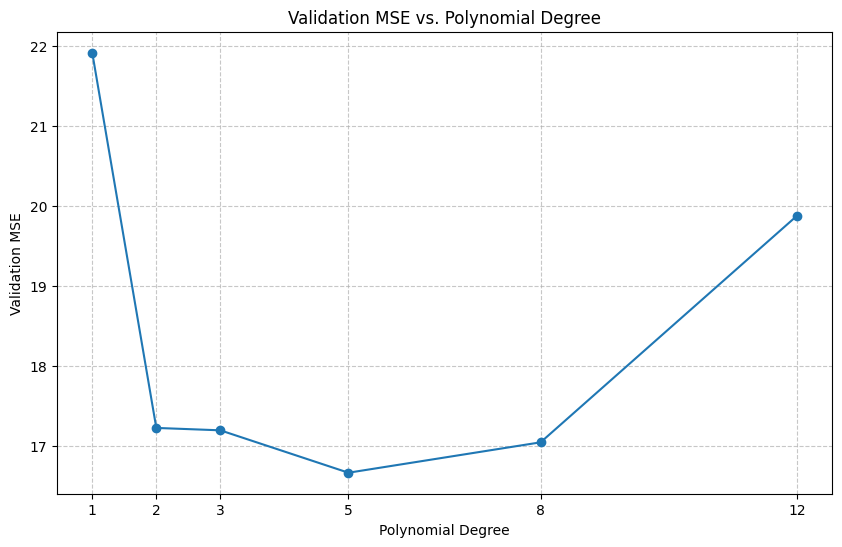

In [14]:
import matplotlib.pyplot as plt

degrees = [1, 2, 3, 5, 8, 12]
# The `val_mse` values were printed in the previous cell's output. We need to manually collect them.
# Assuming the last execution of fHGemFV96H3s produced these values:
val_mses = [21.91, 17.22, 17.19, 16.66, 17.04, 19.87]

plt.figure(figsize=(10, 6))
plt.plot(degrees, val_mses, marker='o', linestyle='-')
plt.title('Validation MSE vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Validation MSE')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()